<h1 div class='alert alert-success'><center> Tunning Hyperparameters Rede Neural

 </center></h1>

![](https://storage.googleapis.com/kaggle-competitions/kaggle/26480/logos/header.png?t=2021-04-09-00-57-05)

# <div class="alert alert-success">  1. IMPORTAÇÕES </div>

## 1.1. Instalações

In [1]:
#!pip install --quiet optuna
!pip install --q GPUtil

## 1.2. Bibliotecas

In [2]:
import warnings
import os
import gc
import random
import glob
import optuna
import time
import torch

In [3]:
import pandas               as pd
import numpy                as np
import matplotlib.pyplot    as plt 
import seaborn              as sns
import joblib               as jb

In [4]:
from sklearn                       import metrics
from sklearn.model_selection       import train_test_split, KFold, StratifiedKFold 
from sklearn.preprocessing         import QuantileTransformer,  KBinsDiscretizer
from sklearn.preprocessing         import PowerTransformer, StandardScaler, MinMaxScaler
from sklearn.pipeline              import make_pipeline
from sklearn.compose               import make_column_transformer

In [5]:
from optuna.samplers               import TPESampler
from optuna.visualization          import plot_edf
from optuna.visualization          import plot_optimization_history
from optuna.visualization          import plot_parallel_coordinate
from optuna.visualization          import plot_param_importances
from optuna.visualization          import plot_slice
from optuna.visualization          import plot_intermediate_values
from optuna.visualization          import plot_contour
from optuna.pruners                import MedianPruner

In [6]:
from GPUtil                        import showUtilization as gpu_usage
from psutil                        import virtual_memory
from datetime                      import datetime

In [7]:
import tensorflow as tf

In [8]:
from tensorflow                    import keras
from tensorflow.keras              import layers
from tensorflow.keras              import callbacks

## 1.3. Funções

In [9]:
def jupyter_setting():
    
    %matplotlib inline
     
    pd.options.display.max_columns = None
    
    optuna.logging.set_verbosity(optuna.logging.WARNING)
      
    warnings.filterwarnings(action='ignore')
    warnings.simplefilter('ignore')
    warnings.filterwarnings('ignore')
    warnings.filterwarnings('ignore', category=DeprecationWarning)
    warnings.filterwarnings('ignore', category=FutureWarning)
    warnings.filterwarnings('ignore', category=RuntimeWarning)
    warnings.filterwarnings('ignore', category=UserWarning)
    #pd.set_option('display.max_rows', 150)
    pd.set_option('display.max_columns', 500)
    pd.set_option('display.max_colwidth', None)

    icecream = ["#00008b", "#960018","#008b00", "#00468b", "#8b4500", "#582c00"]
    #sns.palplot(sns.color_palette(icecream))
    
    return icecream

icecream = jupyter_setting()

In [10]:
#@title
def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
    plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
    plt.rcParams['font.size'] = 12
    plt.title('Precision Recall vs threshold')
    plt.xlabel('Threshold')
    plt.legend(loc="lower left")
    
    plt.grid(True)

In [11]:
def plot_precision_vs_recall(precisions, recalls):
    plt.plot(recalls[:-1], precisions[:-1], "b-", label="Precision")
    
    plt.rcParams['font.size'] = 12
    plt.title('Precision vs recall')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    # plt.legend(loc="lower left")
    
    plt.grid(True)

In [12]:
def plot_roc_curve(fpr, tpr, label=None):
    fig, ax = plt.subplots()
    ax.plot(fpr, tpr, "r-", label=label)
    ax.plot([0, 1], [0, 1], transform=ax.transAxes, ls="--", c=".3")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.0])
    plt.rcParams['font.size'] = 12
    plt.title('ROC curve for TPS 09')
    plt.xlabel('False Positive Rate (1 - Specificity)')
    plt.ylabel('True Positive Rate (Sensitivity)')
    plt.legend(loc="lower right")
    plt.grid(True)

In [13]:
def graf_corr(df):
    
    df = df.corr().round(5)

    # Máscara para ocultar a parte superior direita do gráfico, pois é uma duplicata
    mask = np.zeros_like(df)
    mask[np.triu_indices_from(mask)] = True

    # Making a plot
    plt.figure(figsize=(16,16))
    ax = sns.heatmap(df, annot=True, mask=mask, cmap="RdBu", annot_kws={"weight": "bold", "fontsize":13})

    ax.set_title("Mapa de calor de correlação das variável", fontsize=17)

    plt.setp(ax.get_xticklabels(), 
             rotation      = 90, 
             ha            = "right",
             rotation_mode = "anchor", 
             weight        = "normal")

    plt.setp(ax.get_yticklabels(), 
             weight        = "normal",
             rotation_mode = "anchor", 
             rotation      = 0, 
             ha            = "right");

In [14]:
def correlation(dataset, threshold):

    col_corr    = set()  # Conjunto de todos os nomes de colunas correlacionadas
    corr_matrix = dataset.corr()
    
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) >= threshold: # estamos interessados no valor coeficiente absoluto
                colname = corr_matrix.columns[i]        # obtendo o nome da coluna
                col_corr.add(colname)
    
    return col_corr

In [15]:
def free_gpu_cache():
    
    # https://www.kaggle.com/getting-started/140636
    #print("Initial GPU Usage")
    #gpu_usage()                             

    #cuda.select_device(0)
    #cuda.close()
    #cuda.select_device(0)   
    
    gc.collect()
    torch.cuda.empty_cache()

In [16]:
def seedAll(seed):
    np.random.seed(seed)
    tf.random.set_seed(seed)
    #random.seed(seed)    
    os.environ["PYTHONHASHSEED"] = str(seed)

seed = 12342
seedAll(seed)

## 1.4. GPU

### 1.4.1. Informações

In [17]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)

if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Mon Nov 29 15:12:58 2021       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 450.119.04   Driver Version: 450.119.04   CUDA Version: 11.0     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla P100-PCIE...  Off  | 00000000:00:04.0 Off |                    0 |
| N/A   36C    P0    26W / 250W |      0MiB / 16280MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

### 1.4.2. Memória

In [18]:
ram_gb = virtual_memory().total / 1e9

print('Your runtime has {:.1f} gigabytes of available RAM\n'.format(ram_gb))

if ram_gb < 20:
  print('Not using a high-RAM runtime')
else:
  print('You are using a high-RAM runtime!')

Your runtime has 16.8 gigabytes of available RAM

Not using a high-RAM runtime


## 1.5. Carregar Dados

In [19]:
!mkdir img
!mkdir Data
!mkdir Data/pkl
!mkdir Data/submission
!mkdir Data/submission/tunning

!mkdir model
!mkdir model/mdl
!mkdir model/preds
!mkdir model/optuna
!mkdir model/preds/param
            
!mkdir model/preds/test
!mkdir model/preds/test/n1
!mkdir model/preds/test/n2
!mkdir model/preds/test/n3

!mkdir model/preds/train
!mkdir model/preds/train/n1
!mkdir model/preds/train/n2
!mkdir model/preds/train/n3
!mkdir model/preds/param

mkdir: cannot create directory ‘model/preds/param’: File exists


In [20]:
path = '../input/tps11002/'
#path = ''

In [21]:
df3_train     = jb.load(path + 'df2_nb_02_train.pkl.z')
df3_test      = jb.load(path + 'df2_nb_02_test.pkl.z')
df_submission = pd.read_csv('../input/tabular-playground-series-nov-2021/sample_submission.csv')

df3_train.shape, df3_test.shape, df_submission.shape

((600000, 111), (540000, 110), (540000, 2))

In [22]:
df3_train.head()

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16,f17,f18,f19,f20,f21,f22,f23,f24,f25,f26,f27,f28,f29,f30,f31,f32,f33,f34,f35,f36,f37,f38,f39,f40,f41,f42,f43,f44,f45,f46,f47,f48,f49,f50,f51,f52,f53,f54,f55,f56,f57,f58,f59,f60,f61,f62,f63,f64,f65,f66,f67,f68,f69,f70,f71,f72,f73,f74,f75,f76,f77,f78,f79,f80,f81,f82,f83,f84,f85,f86,f87,f88,f89,f90,f91,f92,f93,f94,f95,f96,f97,f98,f99,target,fe_cluster_0,fe_cluster_1,fe_cluster_2,fe_cluster_3,fe_cluster_4,fe_mean,fe_median,fe_min,fe_max,fe_skew
0,0.106628,3.593750,132.7500,3.183594,0.081970,1.188477,3.732422,2.265625,2.099609,0.012329,1.607422,-0.318115,0.560059,2.806641,1.351562,2.535156,0.197510,0.676270,1.990234,-3.841797,0.037384,0.230347,3.330078,0.009399,0.144775,3.050781,1.303711,0.033234,-0.018280,2.748047,-0.009293,-0.036285,-0.049866,0.019485,3.898438,11.289062,1.137695,3.367188,4.945312,-0.105774,2.113281,3.453125,0.789551,1.113281,1.491211,2.439453,0.041809,3.355469,0.053680,1.701172,0.908691,0.094910,0.030212,0.597168,4.445312,1.586914,-0.068665,-0.108276,0.061035,0.046112,0.017105,-0.027557,0.019485,-0.048828,0.050751,3.728516,5.015625,4.187500,0.063354,0.121033,1.372070,4.015625,0.167603,0.039764,2.042969,-0.016617,0.107666,3.507812,0.013657,-0.097046,5.394531,0.244507,3.492188,0.113098,-0.015472,4.207031,4.105469,0.037231,-0.118835,0.067078,0.010742,1.098633,0.013329,-0.011719,0.052765,0.065430,4.210938,1.978516,0.085999,0.240479,0,1,0,0,0,0,2.650391,0.242432,-3.841797,132.7500,9.687500
1,0.125000,1.673828,76.5625,3.378906,0.099426,5.093750,1.275391,-0.471436,4.546875,0.037720,0.331787,0.325195,0.062042,2.261719,4.339844,-0.224976,0.233643,3.380859,1.903320,0.067871,-0.051270,0.006134,2.603516,0.103455,0.067627,4.753906,1.855469,-0.181885,0.008362,3.166016,0.011848,0.022293,0.069336,0.117126,0.315186,24.484375,1.671875,-0.409180,4.953125,0.092346,2.603516,1.955078,0.005898,3.289062,2.564453,0.817871,0.026001,4.617188,1.575195,0.066101,0.681641,0.025253,0.183472,0.110046,2.746094,0.835449,0.188232,4.960938,0.136108,-0.008492,-0.015266,-0.010841,0.064575,0.102539,0.093628,0.963867,0.630371,4.308594,0.091309,-0.036346,3.617188,3.103516,0.000657,0.051300,1.924805,0.123291,-0.022675,1.547852,-0.010399,0.058319,3.662109,-0.118408,2.357422,-0.009109,0.178711,4.097656,3.533203,0.005245,0.121399,0.109985,0.135864,3.460938,0.017059,0.124878,0.154053,0.606934,-0.267822,2.578125,-0.020874,0.024719,0,1,0,0,0,0,2.136719,0.145020,-0.471436,76.5625,8.429688
2,0.036316,1.497070,233.5000,2.195312,0.026917,3.126953,5.058594,3.849609,1.801758,0.057007,0.328613,2.968750,0.105225,2.070312,5.308594,1.354492,-0.261963,1.378906,1.480469,0.020538,-0.008804,0.109375,1.683594,0.038177,0.123718,1.112305,3.572266,0.120605,0.082092,2.234375,0.002270,0.045197,0.014404,0.011597,-0.502930,33.750000,1.417969,1.071289,3.222656,2.121094,3.082031,0.637695,-0.006821,-0.390869,17.343750,3.701172,-0.033600,1.578125,0.051971,-0.002005,2.691406,0.018372,-0.030472,0.111389,2.187500,-0.324951,-0.019943,3.455078,0.068115,-0.009811,-0.010628,0.027573,-0.007122,-0.048920,-0.002575,1.865234,2.404297,0.411621,0.057739,0.525391,2.167969,0.828125,0.089844,0.093750,4.949219,-0.010979,0.076660,0.266846,0.038696,0.382812,3.847656,-0.121460,3.740234,0.147095,-0.016571,0.614746,2.125000,0.078857,0.979980,0.026764,0.117310,4.882812,0.085205,0.032410,0.116089,-0.001689,-0.520020,2.140625,0.124451,0.148193,0,0,0,0,0,1,3.814453,0.124084,-0.520020,233.5000,9.609375
3,-0.014076,0.245972,780.0000,1.890625,0.006947,1.531250,2.697266,4.515625,4.503906,0.123474,1.002930,4.871094,0.058411,2.498047,1.238281,2.347656,0.175415,1.609375,2.029297,0.042084,0.005142,0.076477,1.651367,0.111816,0.121643,0.589355,4.238281,-0.032837,0.058167,0.712891,0.097473,0.072754,0.000324,0.063354,4.062500,25.375000,0.576660,2.025391,2.968750,1.085938,1.710938,1.372070,0.034637,0.722656,71.437500,3.035156,0.092224,3.453125,0.044830,0.027191,4.082031,0.046967,0.063721,0.029221,0.671875,0.185303,0.164307,3.804688,0.062317,-0.021408,0.009468,0.110901

In [23]:
df3_test.head()

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16,f17,f18,f19,f20,f21,f22,f23,f24,f25,f26,f27,f28,f29,f30,f31,f32,f33,f34,f35,f36,f37,f38,f39,f40,f41,f42,f43,f44,f45,f46,f47,f48,f49,f50,f51,f52,f53,f54,f55,f56,f57,f58,f59,f60,f61,f62,f63,f64,f65,f66,f67,f68,f69,f70,f71,f72,f73,f74,f75,f76,f77,f78,f79,f80,f81,f82,f83,f84,f85,f86,f87,f88,f89,f90,f91,f92,f93,f94,f95,f96,f97,f98,f99,fe_cluster_0,fe_cluster_1,fe_cluster_2,fe_cluster_3,fe_cluster_4,fe_mean,fe_median,fe_min,fe_max,fe_skew
0,0.003229,4.839844,585.5000,2.283203,0.713379,3.908203,0.480713,1.482422,4.890625,0.056335,4.199219,3.152344,0.000349,1.851562,2.638672,0.746582,-0.004757,1.610352,4.113281,-0.077759,0.129395,0.053314,0.416748,0.445068,0.150513,5.019531,2.220703,-0.072327,-0.215820,1.562500,0.074890,0.010048,0.018585,0.067444,5.578125,3.085938,3.841797,0.011124,2.359375,0.695312,-0.345703,4.386719,0.054932,2.802734,3.873047,3.974609,0.157837,0.704590,-0.001125,-0.004547,1.010742,0.094482,0.016937,0.100891,4.367188,1.832031,0.019684,1.963867,0.120605,0.080261,0.027512,0.048828,0.074646,0.041260,0.069336,4.250000,2.091797,0.694824,0.007465,-0.017883,1.883789,1.267578,0.023743,0.043060,3.173828,0.074341,0.125854,3.925781,0.046906,-0.042297,3.019531,0.089539,3.201172,0.009682,-0.099670,3.572266,4.796875,0.091980,0.773438,0.073364,0.112915,1.073242,0.122131,0.086304,0.036011,0.010620,0.290283,1.898438,0.131592,0.012047,1,0,0,0,0,7.078125,0.154175,-0.345703,585.500000,9.992188
1,0.008598,0.505371,-100.1250,3.011719,0.027206,1.194336,5.035156,2.517578,4.554688,0.063904,0.337158,4.441406,0.013191,3.378906,3.384766,1.166992,2.246094,1.750000,2.765625,-0.058502,0.012596,0.036133,0.769043,0.017502,0.050293,0.324707,4.949219,0.124817,0.347168,1.245117,0.035828,-0.013191,0.023193,0.006443,4.984375,23.703125,8.289062,4.796875,1.798828,-0.050049,1.973633,1.912109,0.035980,2.572266,6.320312,0.442627,0.148071,1.311523,0.106689,0.625977,2.310547,-0.044342,0.194336,0.131470,4.265625,0.715820,0.017120,2.839844,0.104736,-0.007950,0.067627,0.066467,0.034271,0.605957,0.019989,-0.456787,3.378906,1.900391,0.052307,-0.050385,2.613281,3.113281,0.022308,0.108337,4.617188,0.091431,0.039368,3.035156,1.023438,-0.020584,2.771484,3.308594,5.058594,-0.003994,0.067627,0.995605,2.470703,-0.015213,0.263428,-0.021912,-0.020218,2.623047,0.123291,0.033051,0.123047,0.005772,-0.392822,3.689453,0.047424,0.119995,0,0,1,0,0,0.551270,0.293945,-100.125000,23.703125,-8.796875
2,1.460938,2.437500,-112.9375,3.541016,0.752441,4.339844,1.648438,4.699219,1.950195,0.005302,2.072266,0.546387,0.141724,1.672852,4.304688,1.702148,-0.062866,1.619141,4.191406,0.055145,-0.016586,0.017807,3.064453,0.070374,0.098328,3.507812,1.069336,0.012749,0.009979,3.468750,0.035919,-0.009804,0.065735,-0.004726,5.281250,11.531250,0.171753,4.394531,2.521484,0.079346,5.453125,1.786133,0.029617,3.064453,5.277344,0.315918,0.148315,0.463135,-0.039948,0.150635,3.753906,0.024170,0.107483,0.048737,3.582031,0.966309,-0.058960,1.870117,0.029877,-0.044281,0.065186,-0.003328,-0.001950,0.095032,0.080261,3.337891,3.605469,4.695312,0.075623,-0.088257,1.772461,-0.142212,0.000918,0.021484,0.241821,0.067566,-0.026566,0.895020,0.111633,0.524414,1.450195,0.019348,1.271484,0.076050,0.447021,4.406250,2.447266,-0.041168,0.212402,0.140991,-0.011032,2.029297,-0.000426,0.084106,0.123596,0.499512,4.054688,3.330078,0.108826,0.064697,0,1,0,0,0,0.224365,0.192139,-112.937500,11.531250,-9.570312
3,0.140503,3.085938,179.5000,0.573730,0.057343,2.216797,1.623047,0.526367,1.542969,-0.026154,1.609375,1.723633,-0.019562,1.551758,4.832031,1.501953,0.192627,4.613281,1.470703,-0.010033,0.072815,0.048035,3.230469,-0.031555,0.028702,3.751953,4.949219,-0.174561,-0.033478,2.478516,0.068115,0.090820,0.029877,0.146729,3.169922,-12.984375,3.134766,1.764648,3.253906,0.713379,3.730469,2.652344,0.080933,1.056641,1.452148,1.814453,0.077881,2.720703,0.004532,0.108826,2.833984,0.024643,-0.051422,0.060577,3.419922,1.283203,-0.083191,0.048828,-0.002502,0.051392,0.075806,-0.008904,0.1417

# <div class="alert alert-success"> 2. Split Train/Test </div>

In [24]:
X      = df3_train.drop(['target'], axis=1)    
y      = df3_train["target"].copy()
X_test = df3_test

del df3_train , df3_test

free_gpu_cache()   

# <div class="alert alert-success"> 3.  TUNNING </div>

## 3.1. Classe Tunning 

### 3.1.1. Pipeline de transformações

In [25]:
feature_int      = X_test.filter(regex=r'f[0-9]').columns.to_list()
feature_cluster  = X_test.filter(regex=r'fe_clu').columns.to_list()
feature_static   = X_test.filter(regex=r'fe_[m-s]').columns.to_list()
feature_pipeline = make_pipeline(StandardScaler(),MinMaxScaler(feature_range=(0, 1)))

preprocessor = make_column_transformer((feature_pipeline, feature_int), 
                                       (feature_pipeline, feature_cluster), 
                                       (feature_pipeline, feature_static),
                                       n_jobs=-1
                                      )

#xx = preprocessor.fit_transform(X.head(300))
#pd.DataFrame(xx).head()

In [26]:
def load_model(learning_rate_, activation_, input_shape_, dropout_=0):
    
    early_stopping = callbacks.EarlyStopping(patience             = 20,
                                             min_delta            = 0,
                                             monitor              = 'val_loss',
                                             restore_best_weights = True,
                                             verbose              = 0,
                                             mode                 = 'min', 
                                             baseline             = None,)
    
    plateau = callbacks.ReduceLROnPlateau(monitor  = 'val_loss', 
                                          factor   = 0.2, 
                                          patience = 7, 
                                          verbose  = 0,
                                          mode     = 'min')
    
    # -----------------------------------------------------------------
    # Model 
    # https://machinelearningmastery.com/choose-an-activation-function-for-deep-learning/
    # https://www.kaggle.com/ryanholbrook/stochastic-gradient-descent
    # https://www.kaggle.com/sfktrkl/tps-nov-2021-nn-2 
    # https://www.kaggle.com/javiervallejos/simple-nn-with-good-results-tps-nov-21
    

    model = keras.Sequential([layers.Dense(128, activation = activation_, input_shape = [input_shape_]),      
                              layers.Dense(64, activation = activation_), 
                              #layers.BatchNormalization(),
                              layers.Dropout(dropout_),
                              layers.Dense(32, activation =activation_),
                              layers.Dense(16, activation =activation_),
                              layers.Dense(1, activation='sigmoid'),
                              ])
    
    # -----------------------------------------------------------------

    model.compile(optimizer = keras.optimizers.Adam(learning_rate=learning_rate_),
                  loss      = 'binary_crossentropy',
                  metrics   = ['AUC'],
                  )
    
    return model, early_stopping, plateau

In [27]:
path=''

class TunningModels():
    
    def __init__(self, name_model_, X_trn_, y_trn_, X_ts_, feature_=None, seed_=12359, path_=''):
        
        super(TunningModels,self).__init__() 

        self.name_clf         = name_model_
        self.X_trn            = X_trn_
        self.y_trn            = y_trn_
        self.X_ts             = X_ts_         
        self.feature          = feature_
        self.seed             = seed_
        self.path             = path_
        
    def diff(t_a, t_b):
        from dateutil.relativedelta import relativedelta
        t_diff = relativedelta(t_b, t_a)  # later/end time comes first!
        return '{h}h {m}m {s}s'.format(h=t_diff.hours, m=t_diff.minutes, s=t_diff.seconds)
        
    def delete_files(namefile):

        path = ['model/train', 'model/test', 'model/valid', 'model/params', 'model/score',
                'model/test_f', 'model/cv_model', 'model/preds', 'model/optuna', 
                'model/preds/train', 'model/preds/test', 'model/preds/test/n1', 
                'model/preds/test/n2', 'model/preds/test/n3', 'model/preds/train/n1', 
                'model/preds/train/n2', 'model/preds/train/n3','model/preds/param', 
                'Data/submission/tunning', 'Data/submission'
                
               ]

        for path_ in path:
            for raiz, diretorios, arquivos in os.walk(path_):
                for arquivo in arquivos:
                    if arquivo.startswith(namefile):
                        os.remove(os.path.join(raiz, arquivo))
        
    def save_data_model(model_, model_name_, path_, y_pred_train_prob_, y_pred_test_prob_,
                     score_, seed_, level_='1', target_='target'):

        level_ = 'n'+ level_ + '/'

        if score_>.5:          

            path_name_param = path_ + 'model/preds/param/' + model_name_.format(score_, seed_)
            path_name_train = path_ + 'model/preds/train/' + level_ + model_name_.format(score_, seed_)
            path_name_test  = path_ + 'model/preds/test/'  + level_ + model_name_.format(score_, seed_)    
            path_name_model = path_ + 'model/mdl/'         + model_name_.format(score_, seed_)    

            jb.dump(y_pred_train_prob_, path_name_train)
            jb.dump(y_pred_test_prob_, path_name_test)
            #jb.dump(model_, path_name_model)
            #jb.dump(pd.DataFrame([model_.get_params()]), path_name_param)   

            if score_>.5:
                # Gerar o arquivo de submissão 
                df_submission[target_] = y_pred_test_prob_
                name_file_sub =  path_ + 'Data/submission/tunning/' + model_name_.format(score_, seed_) + '.csv'
                df_submission.to_csv(name_file_sub, index = False)

    def preprocessor(X_trn_, X_val_, X_tst_): 
        sc_1 = StandardScaler()
        sc_2 = MinMaxScaler(feature_range=(0, 1))

        X_trn = sc_1.fit_transform(X_trn_)
        X_val = sc_1.transform(X_val_)
        X_tst = sc_1.transform(X_tst_)

        X_trn = sc_2.fit_transform(X_trn_)
        X_val = sc_2.transform(X_val_)
        X_tst = sc_2.transform(X_tst_)

        return X_trn, X_val, X_tst
    
    def df_return_preds_tunning(model_name=None, level=1, target_='target'): 
    
        if level==1: 
            level_ = 'n1'
        else: 
            if level==2:
                level_ = 'n2'
            else: 
                level_ = 'n3'
        
        paths = ['model/preds/test/n1', 'model/preds/train/' + level_ ]    

        if model_name==None: 
            model_name=''
            
        for i, path in enumerate(paths): 

            name_file_pkl     = glob.glob(path + '/'+ model_name + '*.pkl.z')
            dic_preds_mdl_pkl = dict()

            for p_name in name_file_pkl:    
                y_model_pkl_name_col  = p_name.replace(path +'/', '').replace('.pkl.z','') 
                y_model_pkl           = jb.load(p_name)   

                dic_preds_mdl_pkl[y_model_pkl_name_col] = y_model_pkl

            if i==0: 
                X_test_pred_nivel_1 = pd.DataFrame(dic_preds_mdl_pkl)
            else: 
                X_train_pred_nivel_1 = pd.DataFrame(dic_preds_mdl_pkl)

        X_train_pred_nivel_1[target_] = y
        
        return X_train_pred_nivel_1, X_test_pred_nivel_1
    
    def cross_valid(model_name_, X_train_, y_train_, X_test_, epochs_, learning_rate_, batch_size_, 
                    activation_, fold_, target_, path_, level_,  print_result_, seed_,
                    dropout_=0, feature_=None, save_predict_=True):

        if feature_!=None: 
            X_train_ = X_train_[feature_]
            X_test_  = X_test_[feature_]
                    
        #--------------------------------------------------------  
        # Scorpo de variáveis
        #--------------------------------------------------------

        time_pred_start    = datetime.now()
        clf_name           = 'Rede Neural TensorFlow'
        preds_valid_f      = {}
        preds_test         = []
        total_auc          = []
        f_scores           = []
        auc_mean           = []
        f1_mean            = []
        lloss_mean         = []
        preds_test_prob    = 0    
        df_score_history   = pd.DataFrame()
        df_train_pred_fold = pd.DataFrame()
        random             = str(np.random.rand(1)[0]).replace('.','')
        model_name_        = model_name_ + '_score_{:2.5f}_{}_' + random + '.pkl.z'
        pri_result         = 95

        #--------------------------------------------------------  
        # Início do process de varilidação
        #--------------------------------------------------------
        is_dropout=''

        if dropout_>0: 
            is_dropout='*'

        if print_result_:
            msg = 'Training model: {} - seed {} - Epoch: {} - lr: {} {}'
            print('='*pri_result)            
            print(msg.format(clf_name, seed_, epochs_, learning_rate_, is_dropout))
            print('='*pri_result)

        kf = StratifiedKFold(n_splits=fold_, random_state=seed, shuffle=True)

        for fold,(idx_train, idx_val) in enumerate(kf.split(X_train_, y_train_, groups=y_train_)):

            time_fold_start = datetime.now()

            #--------------------------------------------------------  
            # Seleção dos dados
            #--------------------------------------------------------
            X_trn, X_val = X_train_.iloc[idx_train], X_train_.iloc[idx_val]
            y_trn, y_val = y_train_.iloc[idx_train], y_train_.iloc[idx_val]
            index_valid  = X_val.index.tolist() 

            #--------------------------------------------------------  
            # Processamento
            #--------------------------------------------------------
            X_trn = preprocessor.fit_transform(X_trn)
            X_val = preprocessor.transform(X_val)    
            X_tst = preprocessor.transform(X_test_.copy())               
            #X_trn, X_val, X_tst= TunningModels.preprocessor(X_trn, X_val, X_test_.copy())
            
            #--------------------------------------------------------  
            # Modelo
            #--------------------------------------------------------
            model, early_stopping, plateau = load_model(learning_rate_,
                                                        activation_, 
                                                        X_trn.shape[1], 
                                                        dropout_
                                                        )

            history = model.fit(X_trn, 
                                y_trn,
                                validation_data       = (X_val, y_val),
                                batch_size            = batch_size_, 
                                epochs                = epochs_,
                                callbacks             = [early_stopping, plateau],
                                validation_batch_size = len(y_val), ##
                                shuffle               = True,
                                verbose               = 0
                                )
            
            #--------------------------------------------------------  
            # oof
            #--------------------------------------------------------
            preds_valid = model.predict(X_val).reshape(1,-1)[0] 
            y_pred      = (preds_valid>.5).astype(int)

            #--------------------------------------------------------  
            # Obtenha os valores médios de cada fold para a previsão
            #--------------------------------------------------------
            #preds_test_prob.append(model.predict(X_test_).reshape(1,-1)[0])
            preds_test_prob += model.predict(X_tst).reshape(1,-1)[0].clip(0,1e10) / fold_
            # test_predictions_nn += model.predict([tt]).reshape(1,-1)[0].clip(0,1e10)/n_folds  
            
            #--------------------------------------------------------  
            # Salvar score de treinamento em um DataFrame 
            #--------------------------------------------------------
            df_scores_fold          = pd.DataFrame(history.history)
            df_scores_fold['folds'] = fold     
            df_score_history        = pd.concat([df_score_history, df_scores_fold], axis=0)

            #--------------------------------------------------------  
            # Concatenar validação e predição
            #--------------------------------------------------------        
            df_val_pred_fold = pd.DataFrame({'fold'     : fold+1,
                                             'index'    : index_valid, 
                                             'pred_val' : preds_valid, 
                                             'target'   : y_val})

            df_train_pred_fold = pd.concat([df_train_pred_fold, df_val_pred_fold], axis=0)

            #--------------------------------------------------------  
            # Métricas 
            #--------------------------------------------------------
            auc   = metrics.roc_auc_score(y_val, y_pred)
            f1    = metrics.f1_score(y_val, y_pred)
            lloss = metrics.log_loss(y_val, preds_valid)   

            auc_mean.append(auc)   
            f1_mean.append(f1)    
            lloss_mean.append(lloss) 

            msg = 'Fold: {} - AUC: {:2.5f} - F1-score: {:2.5f} - L.Loss: {:2.5f} - {}'

            #--------------------------------------------------------  
            # Print resultado Fold
            #--------------------------------------------------------
            time_fold_start_end = TunningModels.diff(time_fold_start, datetime.now())
            print(msg.format(fold+1, auc, f1, lloss, time_fold_start_end))

        #del X_trn, y_trn, X_val, y_val

        df_train_pred_fold.sort_values("index", axis=0, ascending=True, inplace=True)

        #--------------------------------------------------------  
        # Salvar predição em disco
        #--------------------------------------------------------
        X_train_prob      = df_train_pred_fold['pred_val'].to_list()
        score             = np.mean(auc_mean)
        y_pred_test_prob_ = preds_test_prob # np.mean(preds_test_prob, axis=0)

        if save_predict_:
            TunningModels.save_data_model(model_             = model, 
                                          model_name_        = model_name_, 
                                          path_              = path_, 
                                          y_pred_train_prob_ = X_train_prob, 
                                          y_pred_test_prob_  = y_pred_test_prob_, 
                                          score_             = score, 
                                          seed_              = seed_, 
                                          level_             = level_, 
                                          target_            = target_
                                          )  

        #--------------------------------------------------------  
        # Print média dos Folds
        #--------------------------------------------------------
        time_pred_end = TunningModels.diff(time_pred_start, datetime.now())

        if print_result_:
            msg = '[Mean Fold]  AUC: {:.5f}(Std:{:.5f}) - F1: {:.5f} - L. Loss: {:.5f}  {}'        
            print('-'*pri_result)            
            print(msg.format(np.mean(auc_mean),np.std(auc_mean) , np.mean(f1_mean), np.mean(lloss_mean), time_pred_end))
            print('='*pri_result)
            print()

        return model, score, y_pred_test_prob_, df_score_history, df_train_pred_fold
    
    def nn(self, trial):
        
        params = {'epochs'        : trial.suggest_int('epochs', 600, 1200), 
                  'learning_rate' : trial.suggest_float ('learning_rate', 0.0001, 0.0006 ), 
                  'batch_size'    : trial.suggest_int('batch_size', 2048, 4096),
                  'activation'    : trial.suggest_categorical('activation', ['swish', 'relu']),     
                  'dropout'       : trial.suggest_float('dropout', .0, .5)        
                 }
        
        #if params.get('dropout') < .2:
         #   params.update({'dropout': trial.suggest_float('dropout', .0)})
                    
        _, score, _, _, _ = TunningModels.cross_valid(model_name_    = self.name_clf,
                                                      X_train_       = self.X_trn,
                                                      y_train_       = self.y_trn,
                                                      X_test_        = self.X_ts,
                                                      epochs_        = params.get('epochs'),
                                                      learning_rate_ = params.get('learning_rate'),
                                                      batch_size_    = params.get('batch_size'),
                                                      activation_    = params.get('activation'),
                                                      fold_          = 5,
                                                      target_        ='target',
                                                      path_          = self.path,
                                                      level_         = '1',
                                                      save_predict_  = True,
                                                      print_result_  = True,
                                                      seed_          = self.seed, 
                                                      dropout_       = params.get('dropout')
                                                      )        
        
        print('param = {}'.format(params))
        print()

        return score    

In [28]:
my_seed = seed
def seedAll(seed):
    np.random.seed(seed)
    tf.random.set_seed(seed)
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    
seedAll(my_seed)

In [29]:
# Some parameters to config  https://www.kaggle.com/adityasharma01/simple-nn-tps-nov-21
EPOCHS        = 1000
BATCH_SIZE    = 2048 
ACTIVATION    = 'swish'
LEARNING_RATE = 0.001
FOLDS         = 5
name_model_clf = 'rnn_' 
name_model     = name_model_clf + '01' 

feature_int      = X_test.filter(regex=r'f[0-9]').columns.to_list()
feature_cluster  = X_test.filter(regex=r'fe_clu').columns.to_list()
feature_static   = X_test.filter(regex=r'fe_[m-s]').columns.to_list()
feature_pipeline = make_pipeline(StandardScaler(),MinMaxScaler(feature_range=(0, 1)))

preprocessor = make_column_transformer((feature_pipeline, feature_int), 
                                       (feature_pipeline, feature_cluster), 
                                       (feature_pipeline, feature_static),
                                       n_jobs=-1
                                      )

model, score, y_pred_test, df_score_history, _ = TunningModels.cross_valid(model_name_    = name_model,
                                                                           X_train_       = X,
                                                                           y_train_       = y,
                                                                           X_test_        = X_test,
                                                                           feature_       = None,
                                                                           epochs_        = EPOCHS,
                                                                           learning_rate_ = LEARNING_RATE,
                                                                           batch_size_    = BATCH_SIZE,
                                                                           activation_    = ACTIVATION,
                                                                           fold_          = FOLDS,
                                                                           target_        ='target',
                                                                           path_          = path,
                                                                           level_         = '1',
                                                                           save_predict_  = True,
                                                                           print_result_  = True,
                                                                           seed_          = seed
                                                                             )  

Training model: Rede Neural TensorFlow - seed 12342 - Epoch: 1000 - lr: 0.001 


2021-11-29 15:13:39.687777: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2021-11-29 15:13:39.689125: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2021-11-29 15:13:39.689853: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2021-11-29 15:13:39.690959: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compil

Fold: 1 - AUC: 0.74559 - F1-score: 0.74968 - L.Loss: 0.56557 - 0h 2m 51s
Fold: 2 - AUC: 0.74160 - F1-score: 0.74600 - L.Loss: 0.57018 - 0h 2m 57s
Fold: 3 - AUC: 0.74145 - F1-score: 0.74619 - L.Loss: 0.57004 - 0h 2m 49s
Fold: 4 - AUC: 0.74160 - F1-score: 0.74584 - L.Loss: 0.56977 - 0h 2m 18s
Fold: 5 - AUC: 0.74077 - F1-score: 0.74600 - L.Loss: 0.57004 - 0h 2m 45s
-----------------------------------------------------------------------------------------------
[Mean Fold]  AUC: 0.74220(Std:0.00172) - F1: 0.74674 - L. Loss: 0.56912  0h 13m 46s



In [30]:
!ls Data/submission/tunning/*rnn_01_*

Data/submission/tunning/rnn_01_score_0.74220_12342_06828176778307309.pkl.z.csv


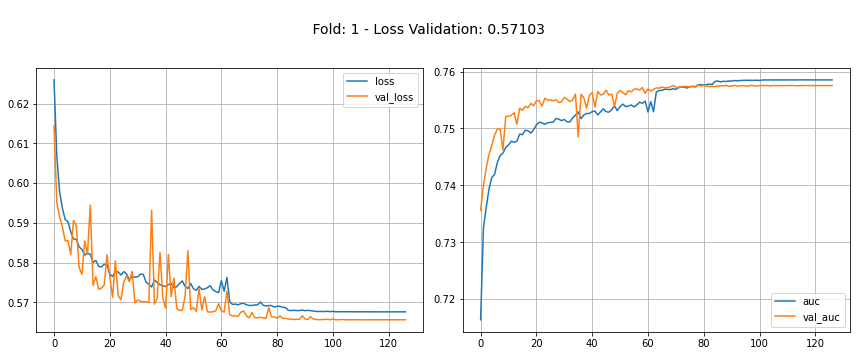

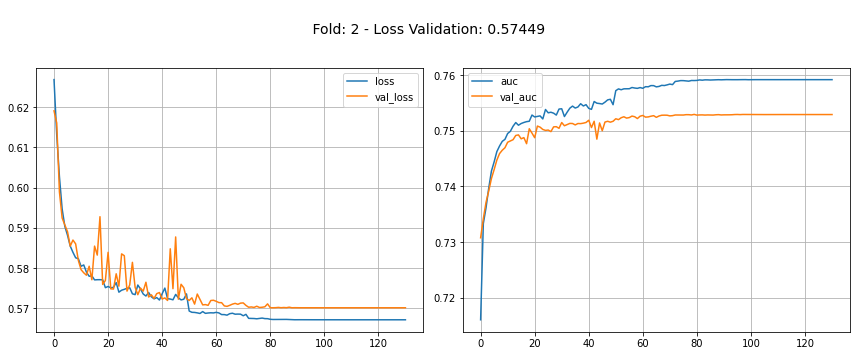

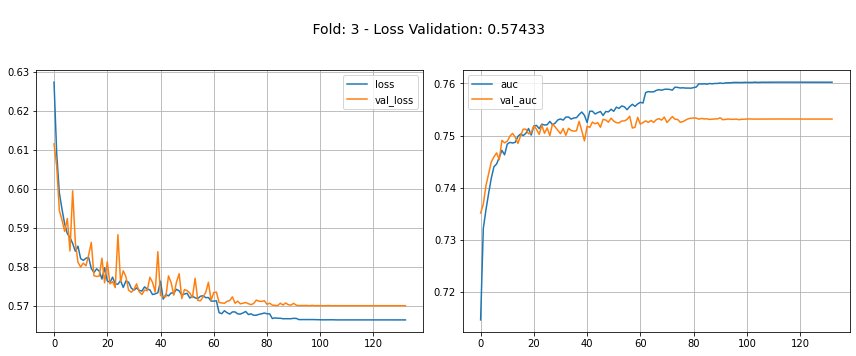

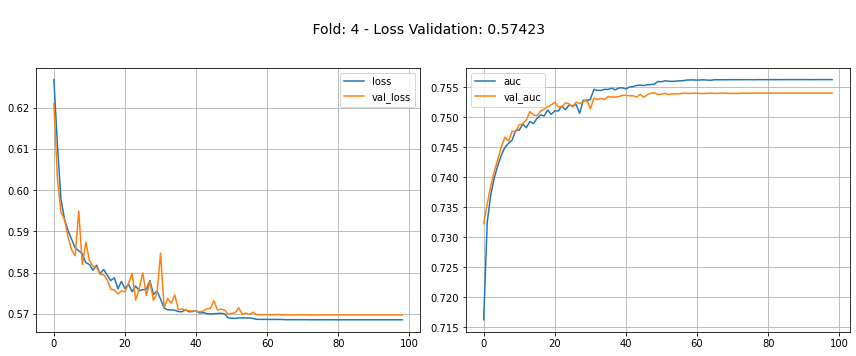

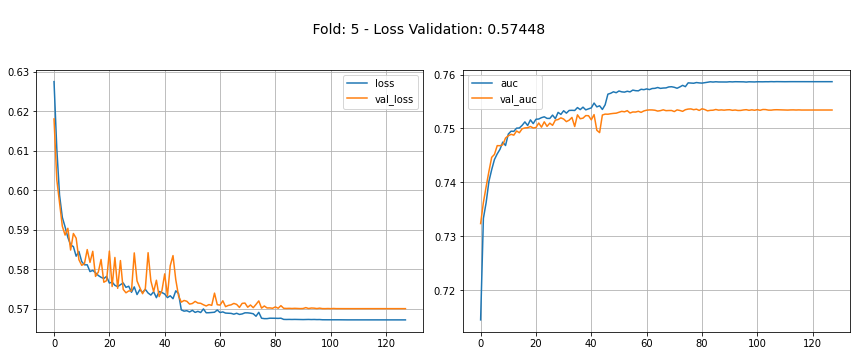

In [31]:
for fold in range(df_score_history['folds'].nunique()):

    history_f = df_score_history[df_score_history['folds'] == fold]
    
    lloss_val = history_f['val_loss'].mean()
    subtitle  = '\n Fold: {} - Loss Validation: {:2.5f} \n'.format(fold+1, lloss_val)
    
    fig, ax = plt.subplots(1, 2, tight_layout=True, figsize=(12,5))
    fig.suptitle(subtitle, fontsize=14)
        
    plt.subplot(1,2,1)
    plt.plot(history_f.loc[:, ['loss', 'val_loss']], label= ['loss', 'val_loss'])
    plt.legend(fontsize=10)
    plt.grid()
    
    #print("Validation Loss: {:0.4f}".format(history_f['val_loss'].min()));
    
    plt.subplot(1,2,2)  
    plt.plot(history_f.loc[:, ['auc', 'val_auc']],label= ['auc', 'val_auc'])
    plt.legend(fontsize=10)
    plt.grid()

### 3.1.2. Tunning Rede Neural

In [32]:
%%time

n_trials_  = 15
score_     = 0
name_model = 'rnn_02_tunning'

TunningModels.delete_files(name_model)

# Inicialize a classe do modelo de otimização
modelOpt = TunningModels(name_model_     = name_model, 
                         X_trn_          = X,
                         y_trn_          = y,
                         X_ts_           = X_test,                                     
                         feature_        = None, 
                         seed_           = seed, 
                         path_           = path
                        )
 
study = optuna.create_study(direction = 'maximize',
                            sampler   = optuna.samplers.TPESampler(seed=seed),
                            pruner    = optuna.pruners.MedianPruner(n_warmup_steps=10),
                            study_name= 'nn_tuning'
                            ) 

study.optimize(modelOpt.nn, n_trials=n_trials_)

score  = study.best_value 
params = study.best_params 

if score > score_ : 
    score_      = score
    seed_best   = seed
    score_best  = score 
    params_best = params
    
print()
print('-'*110)
print('Best score: {:2.5f}'.format(score_best))
print('Seed      : {}'.format(seed_best))
print('Parameters:\n\n{}'.format(params_best))
print()

Training model: Rede Neural TensorFlow - seed 12342 - Epoch: 1010 - lr: 0.0002740323666139822 *
Fold: 1 - AUC: 0.74158 - F1-score: 0.74550 - L.Loss: 0.56861 - 0h 1m 43s
Fold: 2 - AUC: 0.73953 - F1-score: 0.74410 - L.Loss: 0.57124 - 0h 1m 59s
Fold: 3 - AUC: 0.73816 - F1-score: 0.74284 - L.Loss: 0.57233 - 0h 3m 1s
Fold: 4 - AUC: 0.73884 - F1-score: 0.74295 - L.Loss: 0.57137 - 0h 1m 58s
Fold: 5 - AUC: 0.73704 - F1-score: 0.74229 - L.Loss: 0.57258 - 0h 2m 0s
-----------------------------------------------------------------------------------------------
[Mean Fold]  AUC: 0.73903(Std:0.00151) - F1: 0.74353 - L. Loss: 0.57123  0h 10m 46s

param = {'epochs': 1010, 'learning_rate': 0.0002740323666139822, 'batch_size': 3752, 'activation': 'relu', 'dropout': 0.18640819510953038}

Training model: Rede Neural TensorFlow - seed 12342 - Epoch: 710 - lr: 0.00013186493580741684 *
Fold: 1 - AUC: 0.74119 - F1-score: 0.74517 - L.Loss: 0.56871 - 0h 2m 26s
Fold: 2 - AUC: 0.73718 - F1-score: 0.74140 - L.Loss

/opt/conda/lib/python3.7/site-packages/numpy/lib/nanfunctions.py:1544: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr)
/opt/conda/lib/python3.7/site-packages/numpy/lib/nanfunctions.py:1544: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr)
/opt/conda/lib/python3.7/site-packages/numpy/lib/nanfunctions.py:1544: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr)
/opt/conda/lib/python3.7/site-packages/numpy/lib/nanfunctions.py:1544: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr)
/opt/conda/lib/python3.7/site-packages/numpy/lib/nanfunctions.py:1544: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr)
/opt/conda/lib/python3.7/site-packages/numpy/lib/nanfunctions.py:1544: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr)
/opt/conda/lib/python3.7/site-packages/numpy/l

Fold: 2 - AUC: 0.73880 - F1-score: 0.74302 - L.Loss: 0.57199 - 0h 1m 59s
Fold: 3 - AUC: 0.73937 - F1-score: 0.74404 - L.Loss: 0.57176 - 0h 2m 4s
Fold: 4 - AUC: 0.73961 - F1-score: 0.74348 - L.Loss: 0.57056 - 0h 1m 55s
Fold: 5 - AUC: 0.73823 - F1-score: 0.74326 - L.Loss: 0.57187 - 0h 1m 58s
-----------------------------------------------------------------------------------------------
[Mean Fold]  AUC: 0.73962(Std:0.00134) - F1: 0.74397 - L. Loss: 0.57077  0h 10m 0s

param = {'epochs': 1079, 'learning_rate': 0.0005766037143044037, 'batch_size': 2872, 'activation': 'relu', 'dropout': 0.1453094972675399}

Training model: Rede Neural TensorFlow - seed 12342 - Epoch: 902 - lr: 0.0004678548573865923 *
Fold: 1 - AUC: 0.74357 - F1-score: 0.74780 - L.Loss: 0.56795 - 0h 2m 14s
Fold: 2 - AUC: 0.74070 - F1-score: 0.74530 - L.Loss: 0.57057 - 0h 2m 57s
Fold: 3 - AUC: 0.74086 - F1-score: 0.74552 - L.Loss: 0.57065 - 0h 2m 56s
Fold: 4 - AUC: 0.74206 - F1-score: 0.74636 - L.Loss: 0.56908 - 0h 2m 55s
Fol

In [33]:
!ls Data/submission/tunning/*rnn_02_tunning*

Data/submission/tunning/rnn_02_tunning_score_0.73750_12342_01843759667928273.pkl.z.csv
Data/submission/tunning/rnn_02_tunning_score_0.73798_12342_08318921251274477.pkl.z.csv
Data/submission/tunning/rnn_02_tunning_score_0.73903_12342_03480647332279644.pkl.z.csv
Data/submission/tunning/rnn_02_tunning_score_0.73962_12342_09706363862399001.pkl.z.csv
Data/submission/tunning/rnn_02_tunning_score_0.73984_12342_006372987161483368.pkl.z.csv
Data/submission/tunning/rnn_02_tunning_score_0.74006_12342_036791215426489576.pkl.z.csv
Data/submission/tunning/rnn_02_tunning_score_0.74013_12342_021977244412475183.pkl.z.csv
Data/submission/tunning/rnn_02_tunning_score_0.74053_12342_09325641917058749.pkl.z.csv
Data/submission/tunning/rnn_02_tunning_score_0.74062_12342_04350990056781001.pkl.z.csv
Data/submission/tunning/rnn_02_tunning_score_0.74069_12342_037281639021906077.pkl.z.csv
Data/submission/tunning/rnn_02_tunning_score_0.74092_12342_09448174812555208.pkl.z.csv
Data/submission/tunning/rnn_02_tunning_

### Análise 

In [34]:
###################################################################################################
# Plot functions
# --------------
# Visualize the optimization history. See :func:`~optuna.visualization.plot_optimization_history` for the details.
plot_optimization_history(study)

In [35]:
#plot_intermediate_values(study)
###################################################################################################
# Visualize the learning curves of the trials. See :func:`~optuna.visualization.plot_intermediate_values` for the details.
#plot_intermediate_values(study)

In [36]:
###################################################################################################
# Visualize high-dimensional parameter relationships. See :func:`~optuna.visualization.plot_parallel_coordinate` for the details.
plot_parallel_coordinate(study)

In [37]:
###################################################################################################
# Select parameters to visualize.
plot_parallel_coordinate(study, params=["batch_size", "epochs", 'dropout'])

In [38]:
###################################################################################################
# Visualize hyperparameter relationships. See :func:`~optuna.visualization.plot_contour` for the details.
#plot_contour(study)

In [39]:
###################################################################################################
# Select parameters to visualize.
plot_contour(study, params=["batch_size", "epochs"])

In [40]:
###################################################################################################
# Visualize individual hyperparameters as slice plot. See :func:`~optuna.visualization.plot_slice` for the details.
plot_slice(study)

In [41]:
###################################################################################################
# Select parameters to visualize.
plot_slice(study, params=["batch_size", "epochs"])

In [42]:
###################################################################################################
# Visualize parameter importances. See :func:`~optuna.visualization.plot_param_importances` for the details.
#plot_param_importances(study)

In [43]:
###################################################################################################
# Learn which hyperparameters are affecting the trial duration with hyperparameter importance.
# optuna.visualization.plot_param_importances( study, target=lambda t: t.duration.total_seconds(), target_name="duration")

In [44]:
###################################################################################################
# Visualize empirical distribution function. See :func:`~optuna.visualization.plot_edf` for the details.
plot_edf(study)

### 1.2.3. Modelo Final
Agora que temos os melhores parametros, vamos treinar uma modelo com esse parametros e fazer algumas análises. 

In [45]:
X_train, X_valid, y_train, y_valid = train_test_split(X, 
                                                      y, 
                                                      test_size    = 0.2,
                                                      shuffle      = True, 
                                                      stratify     = y,
                                                      random_state = 12359)

X_train.shape, y_train.shape, X_valid.shape, y_valid.shape 

((480000, 110), (480000,), (120000, 110), (120000,))

In [46]:
%%time

EPOCHS        = params_best.get('epochs')
BATCH_SIZE    = params_best.get('batch_size')
ACTIVATION    = params_best.get('activation')
LEARNING_RATE = params_best.get('learning_rate')
FOLDS         = 5
name_model_clf = 'rnn_' 
name_model     = name_model_clf + '03tunning' 

model, score, y_pred_test, df_score_history, _ = TunningModels.cross_valid(model_name_     = name_model,
                                                                            X_train_       = X_train,
                                                                            y_train_       = y_train,
                                                                            X_test_        = X_test,
                                                                            feature_       = None,
                                                                            epochs_        = EPOCHS,
                                                                            learning_rate_ = LEARNING_RATE,
                                                                            batch_size_    = BATCH_SIZE,
                                                                            activation_    = ACTIVATION,
                                                                            fold_          = FOLDS,
                                                                            target_        ='target',
                                                                            path_          = path,
                                                                            level_         = '1',
                                                                            save_predict_  = False,
                                                                            print_result_  = True,
                                                                            seed_          = seed
                                                                            )  

Training model: Rede Neural TensorFlow - seed 12342 - Epoch: 1017 - lr: 0.0005014021717908683 
Fold: 1 - AUC: 0.74061 - F1-score: 0.74516 - L.Loss: 0.57123 - 0h 2m 8s
Fold: 2 - AUC: 0.74314 - F1-score: 0.74720 - L.Loss: 0.56854 - 0h 2m 54s
Fold: 3 - AUC: 0.73979 - F1-score: 0.74490 - L.Loss: 0.57115 - 0h 2m 59s
Fold: 4 - AUC: 0.73825 - F1-score: 0.74259 - L.Loss: 0.57328 - 0h 2m 7s
Fold: 5 - AUC: 0.74169 - F1-score: 0.74625 - L.Loss: 0.56990 - 0h 2m 22s
-----------------------------------------------------------------------------------------------
[Mean Fold]  AUC: 0.74069(Std:0.00166) - F1: 0.74522 - L. Loss: 0.57082  0h 12m 31s

CPU times: user 13min 29s, sys: 1min 16s, total: 14min 45s
Wall time: 12min 31s


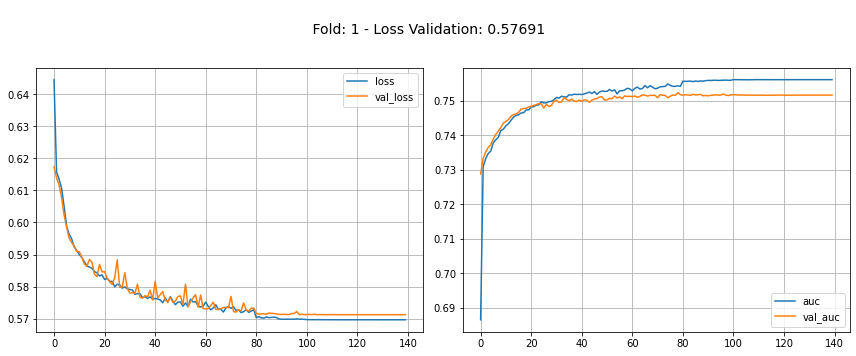

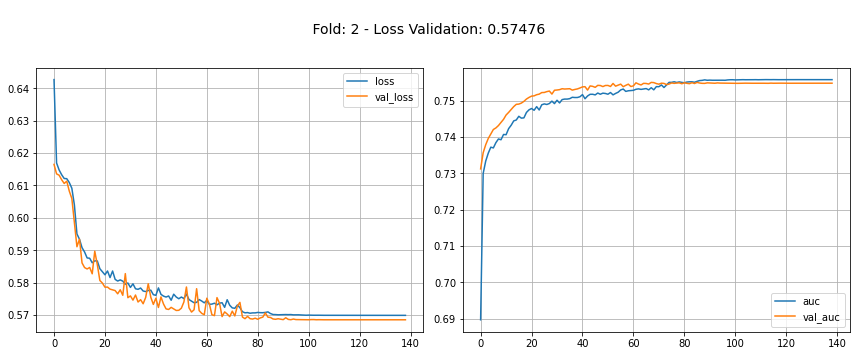

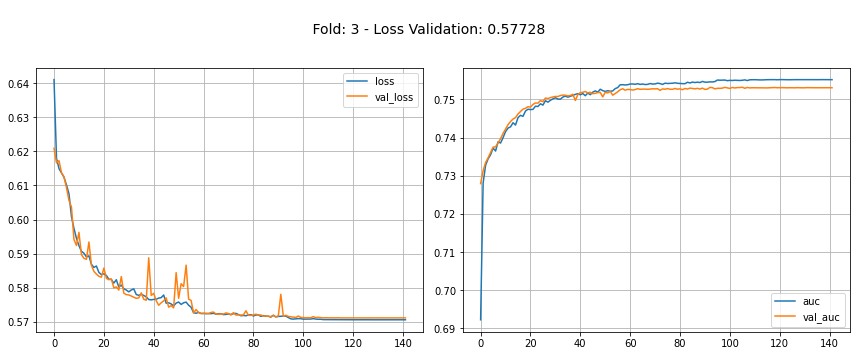

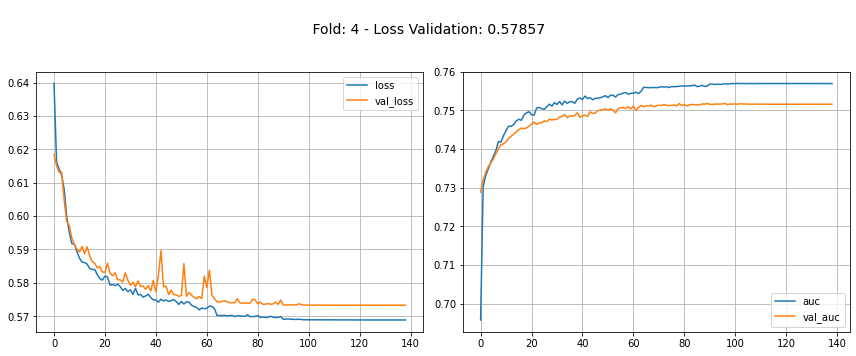

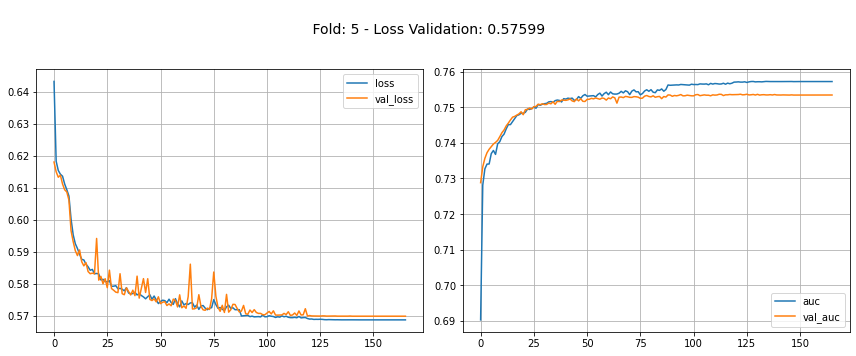

In [47]:
for fold in range(df_score_history['folds'].nunique()):

    history_f = df_score_history[df_score_history['folds'] == fold]
    
    lloss_val = history_f['val_loss'].mean()
    subtitle  = '\n Fold: {} - Loss Validation: {:2.5f} \n'.format(fold+1, lloss_val)
    
    fig, ax = plt.subplots(1, 2, tight_layout=True, figsize=(12,5))
    fig.suptitle(subtitle, fontsize=14)
        
    plt.subplot(1,2,1)
    plt.plot(history_f.loc[:, ['loss', 'val_loss']], label= ['loss', 'val_loss'])
    plt.legend(fontsize=10)
    plt.grid()
        
    plt.subplot(1,2,2)  
    plt.plot(history_f.loc[:, ['auc', 'val_auc']],label= ['auc', 'val_auc'])
    plt.legend(fontsize=10)
    plt.grid()

In [48]:
X_valid_scaler = preprocessor.fit_transform(X_valid)
y_hat_002 = model.predict(X_valid_scaler).reshape(1,-1)[0] 

#### 1.2.3.1. Analise do Modelo

#### 1.2.3.1.1. Curva Roc

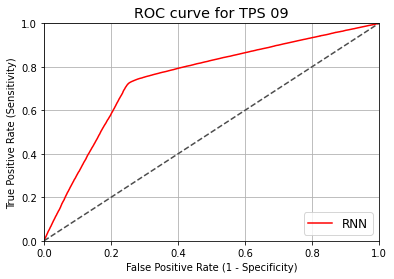

In [49]:
fpr, tpr, thresholds = metrics.roc_curve(y_valid, y_hat_002)
plot_roc_curve(fpr, tpr, label="RNN")
plt.show()

<div class="alert alert-info" role="alert"> 
    
**`NOTA:`** <br>
 

</div>


In [50]:
threshold = .5
f1_002  = metrics.f1_score (y_valid, (y_hat_002 > threshold))
auc_002 = metrics.roc_auc_score(y_valid, y_hat_002 )
print(metrics.classification_report(y_valid, (y_hat_002 > threshold).astype(int) ))
print('')
print('F1-score: {:2.5f}'.format(f1_002))
print('AUC     : {:2.5f}'.format(auc_002))

              precision    recall  f1-score   support

           0       0.69      0.77      0.73     59279
           1       0.75      0.67      0.71     60721

    accuracy                           0.72    120000
   macro avg       0.72      0.72      0.72    120000
weighted avg       0.72      0.72      0.72    120000


F1-score: 0.70724
AUC     : 0.74674


### 1.2.4. Divercidade

#### 1.2.4.1. SEED
Nesta etapa vamos utilizar os melhores parametros, que encontramos na tunagem acima, com `seed` diferentes. 

In [51]:
%%time 

SEED_          = [42, 59,100, 200, 1000, 1500, 2020, 2021, 5000, 10000, 7000]
df_seed        = pd.DataFrame()
seed_best      = seed_best

EPOCHS         = params_best.get('epochs')
BATCH_SIZE     = params_best.get('batch_size')
ACTIVATION     = params_best.get('activation')
LEARNING_RATE  = params_best.get('learning_rate')
FOLDS          = 5
name_model_clf = 'rnn_' 
name_model     = name_model_clf + '004_div_seed' 

TunningModels.delete_files(name_model)

for i, seed_ in  enumerate (SEED_):     
        
    seedAll(seed_)
    
    model, score, y_pred_test, df_score_history, _ = TunningModels.cross_valid(model_name_     = name_model,
                                                                                X_train_       = X,
                                                                                y_train_       = y,
                                                                                X_test_        = X_test,
                                                                                feature_       = None,
                                                                                epochs_        = EPOCHS,
                                                                                learning_rate_ = LEARNING_RATE,
                                                                                batch_size_    = BATCH_SIZE,
                                                                                activation_    = ACTIVATION,
                                                                                fold_          = FOLDS,
                                                                                target_        ='target',
                                                                                path_          = path,
                                                                                level_         = '1',
                                                                                save_predict_  = True,
                                                                                print_result_  = True,
                                                                                seed_          = seed_
                                                                                )  
                
    if score > score_best:         
        seed_best  = seed_
        score_best = score

    df_seed['seed_' + str(seed_)] = y_pred_test 
   
print('Seed best: {}'.format(seed_best))
print('Score    : {:2.5f}'.format(score_best))

Training model: Rede Neural TensorFlow - seed 42 - Epoch: 1017 - lr: 0.0005014021717908683 
Fold: 1 - AUC: 0.74327 - F1-score: 0.74737 - L.Loss: 0.56840 - 0h 2m 17s
Fold: 2 - AUC: 0.74007 - F1-score: 0.74463 - L.Loss: 0.57155 - 0h 2m 23s
Fold: 3 - AUC: 0.73963 - F1-score: 0.74447 - L.Loss: 0.57214 - 0h 2m 10s
Fold: 4 - AUC: 0.74072 - F1-score: 0.74501 - L.Loss: 0.57114 - 0h 2m 17s
Fold: 5 - AUC: 0.73880 - F1-score: 0.74405 - L.Loss: 0.57224 - 0h 2m 20s
-----------------------------------------------------------------------------------------------
[Mean Fold]  AUC: 0.74050(Std:0.00152) - F1: 0.74511 - L. Loss: 0.57109  0h 11m 33s

Training model: Rede Neural TensorFlow - seed 59 - Epoch: 1017 - lr: 0.0005014021717908683 
Fold: 1 - AUC: 0.74421 - F1-score: 0.74821 - L.Loss: 0.56714 - 0h 2m 26s
Fold: 2 - AUC: 0.74057 - F1-score: 0.74509 - L.Loss: 0.57116 - 0h 2m 58s
Fold: 3 - AUC: 0.74073 - F1-score: 0.74542 - L.Loss: 0.57126 - 0h 2m 15s
Fold: 4 - AUC: 0.73855 - F1-score: 0.74303 - L.Loss

/opt/conda/lib/python3.7/site-packages/numpy/lib/nanfunctions.py:1544: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr)
/opt/conda/lib/python3.7/site-packages/numpy/lib/nanfunctions.py:1544: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr)
/opt/conda/lib/python3.7/site-packages/numpy/lib/nanfunctions.py:1544: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr)
/opt/conda/lib/python3.7/site-packages/numpy/lib/nanfunctions.py:1544: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr)
/opt/conda/lib/python3.7/site-packages/numpy/lib/nanfunctions.py:1544: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr)
/opt/conda/lib/python3.7/site-packages/numpy/lib/nanfunctions.py:1544: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr)
/opt/conda/lib/python3.7/site-packages/numpy/l

Fold: 3 - AUC: 0.74103 - F1-score: 0.74563 - L.Loss: 0.57110 - 0h 3m 2s
Fold: 4 - AUC: 0.73972 - F1-score: 0.74436 - L.Loss: 0.57125 - 0h 2m 10s
Fold: 5 - AUC: 0.73949 - F1-score: 0.74498 - L.Loss: 0.57232 - 0h 2m 8s
-----------------------------------------------------------------------------------------------
[Mean Fold]  AUC: 0.74073(Std:0.00181) - F1: 0.74534 - L. Loss: 0.57095  0h 12m 36s

Training model: Rede Neural TensorFlow - seed 1000 - Epoch: 1017 - lr: 0.0005014021717908683 
Fold: 1 - AUC: 0.74411 - F1-score: 0.74829 - L.Loss: 0.56746 - 0h 3m 0s
Fold: 2 - AUC: 0.73893 - F1-score: 0.74374 - L.Loss: 0.57324 - 0h 1m 58s
Fold: 3 - AUC: 0.73955 - F1-score: 0.74435 - L.Loss: 0.57224 - 0h 2m 24s
Fold: 4 - AUC: 0.74071 - F1-score: 0.74508 - L.Loss: 0.57099 - 0h 2m 57s
Fold: 5 - AUC: 0.73936 - F1-score: 0.74435 - L.Loss: 0.57210 - 0h 2m 56s
-----------------------------------------------------------------------------------------------
[Mean Fold]  AUC: 0.74053(Std:0.00188) - F1: 0.7

In [52]:
 df_seed.head()

,seed_42,seed_59,seed_100,seed_200,seed_1000,seed_1500,seed_2020,seed_2021,seed_5000,seed_10000,seed_7000
0,0.731520,0.735559,0.730165,0.730958,0.732864,0.731723,0.731063,0.731955,0.721600,0.726755,0.728805
1,0.756875,0.757382,0.757142,0.752004,0.763913,0.755830,0.757584,0.757454,0.762261,0.761440,0.751316
2,0.749965,0.751188,0.755330,0.757775,0.753884,0.753518,0.749595,0.754950,0.752566,0.751304,0.753802
3,0.463312,0.463338,0.456612,0.439167,0.456483,0.445510,0.438349,0.444405,0.442647,0.435893,0.465027
4,0.739251,0.733877,0.741369,0.728899,0.740758,0.737689,0.735860,0.729469,0.741565,0.740659,0.737521


In [53]:
submission = pd.DataFrame({'id': df_submission.id, 'target': df_seed.mean(axis=1)})
submission.to_csv(path + 'Data/submission/tunning/rnn_005_div_seed_mean.csv', index=False)

In [54]:
!ls Data/submission/tunning/*rnn_005_div*

Data/submission/tunning/rnn_005_div_seed_mean.csv


#### 1.2.4.1. Bath Size

In [55]:
df_bach_size   = pd.DataFrame()
seed_best      = seed_best
bach_size_best = score_best

EPOCHS         = params_best.get('epochs')
BATCH_SIZE     = 2048
ACTIVATION     = params_best.get('activation')
LEARNING_RATE  = params_best.get('learning_rate')
FOLDS          = 5
name_model_clf = 'rnn_' 
name_model     = name_model_clf + '006_div_bach_size' 

TunningModels.delete_files(name_model)

for i, seed_ in  enumerate (range(5)):     
        
    seedAll(seed_best)
         
    model, score, y_pred_test, df_score_history, _ = TunningModels.cross_valid(model_name_    = name_model,
                                                                               X_train_       = X,
                                                                               y_train_       = y,
                                                                               X_test_        = X_test,
                                                                               feature_       = None,
                                                                               epochs_        = EPOCHS,
                                                                               learning_rate_ = LEARNING_RATE,
                                                                               batch_size_    = BATCH_SIZE,
                                                                               activation_    = ACTIVATION,
                                                                               fold_          = FOLDS,
                                                                               target_        ='target',
                                                                               path_          = path,
                                                                               level_         = '1',
                                                                               save_predict_  = True,
                                                                               print_result_  = True,
                                                                               seed_          = seed_best
                                                                                )  
    
    if score > score_best:                
        score_best     = score
        bach_size_best = BATCH_SIZE

    df_bach_size['bach_size_' + str(BATCH_SIZE)] = y_pred_test 
    
    BATCH_SIZE += 1024

print('Seed best: {}'.format(seed_best))
print('Score    : {:2.5f}'.format(score_best))
print('Bach size: {}'.format(bach_size_best))

Training model: Rede Neural TensorFlow - seed 12342 - Epoch: 1017 - lr: 0.0005014021717908683 
Fold: 1 - AUC: 0.74481 - F1-score: 0.74898 - L.Loss: 0.56670 - 0h 3m 1s
Fold: 2 - AUC: 0.74139 - F1-score: 0.74588 - L.Loss: 0.57087 - 0h 3m 2s
Fold: 3 - AUC: 0.74097 - F1-score: 0.74580 - L.Loss: 0.57106 - 0h 3m 2s
Fold: 4 - AUC: 0.74181 - F1-score: 0.74604 - L.Loss: 0.56980 - 0h 2m 42s
Fold: 5 - AUC: 0.73982 - F1-score: 0.74516 - L.Loss: 0.57183 - 0h 2m 58s
-----------------------------------------------------------------------------------------------
[Mean Fold]  AUC: 0.74176(Std:0.00166) - F1: 0.74637 - L. Loss: 0.57005  0h 14m 51s

Training model: Rede Neural TensorFlow - seed 12342 - Epoch: 1017 - lr: 0.0005014021717908683 
Fold: 1 - AUC: 0.74265 - F1-score: 0.74694 - L.Loss: 0.56894 - 0h 2m 9s
Fold: 2 - AUC: 0.74137 - F1-score: 0.74588 - L.Loss: 0.57100 - 0h 2m 28s
Fold: 3 - AUC: 0.73863 - F1-score: 0.74330 - L.Loss: 0.57330 - 0h 2m 5s
Fold: 4 - AUC: 0.74124 - F1-score: 0.74561 - L.Los

/opt/conda/lib/python3.7/site-packages/numpy/lib/nanfunctions.py:1544: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr)
/opt/conda/lib/python3.7/site-packages/numpy/lib/nanfunctions.py:1544: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr)
/opt/conda/lib/python3.7/site-packages/numpy/lib/nanfunctions.py:1544: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr)
/opt/conda/lib/python3.7/site-packages/numpy/lib/nanfunctions.py:1544: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr)
/opt/conda/lib/python3.7/site-packages/numpy/lib/nanfunctions.py:1544: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr)
/opt/conda/lib/python3.7/site-packages/numpy/lib/nanfunctions.py:1544: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr)
/opt/conda/lib/python3.7/site-packages/numpy/l

Fold: 5 - AUC: 0.73886 - F1-score: 0.74418 - L.Loss: 0.57274 - 0h 2m 5s
-----------------------------------------------------------------------------------------------
[Mean Fold]  AUC: 0.74100(Std:0.00179) - F1: 0.74560 - L. Loss: 0.57086  0h 12m 5s

Training model: Rede Neural TensorFlow - seed 12342 - Epoch: 1017 - lr: 0.0005014021717908683 
Fold: 1 - AUC: 0.74305 - F1-score: 0.74741 - L.Loss: 0.56842 - 0h 1m 48s
Fold: 2 - AUC: 0.74065 - F1-score: 0.74505 - L.Loss: 0.57170 - 0h 2m 1s
Fold: 3 - AUC: 0.73954 - F1-score: 0.74413 - L.Loss: 0.57251 - 0h 1m 57s
Fold: 4 - AUC: 0.74067 - F1-score: 0.74494 - L.Loss: 0.57106 - 0h 2m 1s
Fold: 5 - AUC: 0.73853 - F1-score: 0.74412 - L.Loss: 0.57289 - 0h 1m 51s
-----------------------------------------------------------------------------------------------
[Mean Fold]  AUC: 0.74049(Std:0.00150) - F1: 0.74513 - L. Loss: 0.57131  0h 9m 44s

Training model: Rede Neural TensorFlow - seed 12342 - Epoch: 1017 - lr: 0.0005014021717908683 
Fold: 1 - AUC: 

In [56]:
df_bach_size.head() 

,bach_size_2048,bach_size_3072,bach_size_4096,bach_size_5120,bach_size_6144
0,0.738463,0.731697,0.733363,0.732572,0.732526
1,0.751870,0.764568,0.763289,0.768427,0.775766
2,0.752642,0.750305,0.750124,0.749321,0.750363
3,0.432520,0.468256,0.460004,0.480530,0.518176
4,0.729694,0.737094,0.734155,0.733328,0.733468


In [57]:
submission = pd.DataFrame({'id': df_submission.id, 'target': df_bach_size.mean(axis=1)})
submission.to_csv(path + 'Data/submission/tunning/rnn_007_bach_size_meand.csv', index=False)

In [58]:
!ls Data/submission/tunning/*004_div_bach_size*

ls: cannot access 'Data/submission/tunning/*004_div_bach_size*': No such file or directory


#### 1.2.4.3. FEATURE

In [59]:
params_best

{'epochs': 1017,
 'learning_rate': 0.0005014021717908683,
 'batch_size': 2724,
 'activation': 'swish',
 'dropout': 0.13087693841083592}

### 1.2.5. Ensable 

#### 1.2.5.1. Recuparar dataset

In [60]:
%%time 
df_train_rnn, df_test_rnn = TunningModels.df_return_preds_tunning('rnn', target_ ='target') # 
print(df_train_rnn.shape, df_test_rnn.shape)
print()

(600000, 33) (540000, 32)

CPU times: user 45.4 s, sys: 480 ms, total: 45.9 s
Wall time: 46 s


In [61]:
df_train_rnn.head()

,rnn_02_tunning_score_0.73798_12342_08318921251274477,rnn_004_div_seed_score_0.74106_1500_09845150164635289,rnn_02_tunning_score_0.74129_12342_048528219791800176,rnn_02_tunning_score_0.74069_12342_037281639021906077,rnn_02_tunning_score_0.74133_12342_06685268427567358,rnn_004_div_seed_score_0.74073_200_09476322568516703,rnn_004_div_seed_score_0.74081_59_09240351155744253,rnn_02_tunning_score_0.74013_12342_021977244412475183,rnn_02_tunning_score_0.74053_12342_09325641917058749,rnn_02_tunning_score_0.73750_12342_01843759667928273,rnn_006_div_bach_size_score_0.74176_12342_06828176778307309,rnn_004_div_seed_score_0.74053_1000_06535895854646095,rnn_02_tunning_score_0.74107_12342_05297408813792911,rnn_004_div_seed_score_0.74050_42_03745401188473625,rnn_01_score_0.74220_12342_06828176778307309,rnn_02_tunning_score_0.73984_12342_006372987161483368,rnn_006_div_bach_size_score_0.74100_12342_06828176778307309,rnn_004_div_seed_score_0.74127_2021_06059782788074047,rnn_02_tunning_score_0.73903_12342_03480647332279644,rnn_02_tunning_score_0.74133_12342_04804362130993788,rnn_006_div_bach_size_score_0.74072_12342_06828176778307309,rnn_006_div_bach_size_score_0.73926_12342_06828176778307309,rnn_02_tunning_score_0.73962_12342_09706363862399001,rnn_006_div_bach_size_score_0.74049_12342_06828176778307309,rnn_004_div_seed_score_0.74081_5000_022904786524879028,rnn_02_tunning_score_0.74006_12342_036791215426489576,rnn_004_div_seed_score_0.74125_2020_09862768288615988,rnn_004_div_seed_score_0.74070_7000_005524689312628783,rnn_02_tunning_score_0.74092_12342_09448174812555208,rnn_02_tunning_score_0.74062_12342_04350990056781001,rnn_004_div_seed_score_0.74110_100_05434049417909654,rnn_004_div_seed_score_0.74095_10000_05454701510335127,target
0,0.271667,0.259601,0.256293,0.263370,0.253469,0.258385,0.250540,0.248152,0.258350,0.264787,0.244686,0.255595,0.256880,0.260221,0.260385,0.265848,0.229578,0.249737,0.276598,0.259426,0.236402,0.237458,0.251946,0.228296,0.259681,0.258558,0.280063,0.264534,0.257169,0.265799,0.265664,0.253456,0
1,0.212085,0.235309,0.244633,0.246107,0.240620,0.246700,0.223141,0.236742,0.240396,0.241969,0.235309,0.242220,0.237270,0.244588,0.233389,0.243701,0.240473,0.238094,0.236746,0.241647,0.240992,0.240560,0.249493,0.239540,0.235553,0.242013,0.230963,0.251460,0.233723,0.233078,0.233517,0.233450,0
2,0.249843,0.230115,0.227415,0.229218,0.229973,0.250036,0.234282,0.233129,0.234687,0.239435,0.244912,0.239159,0.231186,0.227702,0.226625,0.231996,0.249613,0.229340,0.249556,0.230686,0.248586,0.246451,0.227107,0.251530,0.233043,0.232204,0.225082,0.230467,0.245132,0.232013,0.228638,0.236053,0
3,0.749037,0.751031,0.753159,0.748756,0.741148,0.750087,0.761923,0.748802,0.756379,0.749091,0.748610,0.748056,0.752759,0.760565,0.758727,0.744070,0.753841,0.742743,0.758334,0.750013,0.749681,0.761312,0.750767,0.757911,0.750781,0.754270,0.759083,0.759439,0.745335,0.728318,0.748397,0.762153,0
4,0.745735,0.727953,0.722345,0.735427,0.727683,0.730303,0.739414,0.733397,0.730474,0.737027,0.722505,0.712791,0.722375,0.731190,0.744768,0.724637,0.717795,0.731536,0.737952,0.728659,0.721967,0.721615,0.727274,0.720616,0.719219,0.735404,0.721699,0.717880,0.730607,0.749531,0.726959,0.726148,1


In [62]:
df_test_rnn.head()

,rnn_02_tunning_score_0.73798_12342_08318921251274477,rnn_004_div_seed_score_0.74106_1500_09845150164635289,rnn_02_tunning_score_0.74129_12342_048528219791800176,rnn_02_tunning_score_0.74069_12342_037281639021906077,rnn_02_tunning_score_0.74133_12342_06685268427567358,rnn_004_div_seed_score_0.74073_200_09476322568516703,rnn_004_div_seed_score_0.74081_59_09240351155744253,rnn_02_tunning_score_0.74013_12342_021977244412475183,rnn_02_tunning_score_0.74053_12342_09325641917058749,rnn_02_tunning_score_0.73750_12342_01843759667928273,rnn_006_div_bach_size_score_0.74176_12342_06828176778307309,rnn_004_div_seed_score_0.74053_1000_06535895854646095,rnn_02_tunning_score_0.74107_12342_05297408813792911,rnn_004_div_seed_score_0.74050_42_03745401188473625,rnn_01_score_0.74220_12342_06828176778307309,rnn_02_tunning_score_0.73984_12342_006372987161483368,rnn_006_div_bach_size_score_0.74100_12342_06828176778307309,rnn_004_div_seed_score_0.74127_2021_06059782788074047,rnn_02_tunning_score_0.73903_12342_03480647332279644,rnn_02_tunning_score_0.74133_12342_04804362130993788,rnn_006_div_bach_size_score_0.74072_12342_06828176778307309,rnn_006_div_bach_size_score_0.73926_12342_06828176778307309,rnn_02_tunning_score_0.73962_12342_09706363862399001,rnn_006_div_bach_size_score_0.74049_12342_06828176778307309,rnn_004_div_seed_score_0.74081_5000_022904786524879028,rnn_02_tunning_score_0.74006_12342_036791215426489576,rnn_004_div_seed_score_0.74125_2020_09862768288615988,rnn_004_div_seed_score_0.74070_7000_005524689312628783,rnn_02_tunning_score_0.74092_12342_09448174812555208,rnn_02_tunning_score_0.74062_12342_04350990056781001,rnn_004_div_seed_score_0.74110_100_05434049417909654,rnn_004_div_seed_score_0.74095_10000_05454701510335127
0,0.739269,0.731723,0.739113,0.738438,0.737992,0.730958,0.735559,0.732826,0.740144,0.739461,0.738463,0.732864,0.737704,0.731520,0.736334,0.734855,0.733363,0.731955,0.732781,0.742071,0.731697,0.732526,0.736529,0.732572,0.721600,0.739398,0.731063,0.728805,0.741223,0.736453,0.730165,0.726755
1,0.758416,0.755830,0.749255,0.744154,0.746775,0.752004,0.757382,0.757012,0.748091,0.748542,0.751870,0.763913,0.747947,0.756875,0.749566,0.758675,0.763289,0.757454,0.757499,0.748408,0.764568,0.775766,0.745297,0.768427,0.762261,0.754046,0.757584,0.751316,0.747763,0.746987,0.757142,0.761440
2,0.734593,0.753518,0.755511,0.754176,0.753014,0.757775,0.751188,0.750963,0.753186,0.750084,0.752642,0.753884,0.754019,0.749965,0.747753,0.755846,0.750124,0.754950,0.749408,0.750688,0.750305,0.750363,0.739226,0.749321,0.752566,0.752798,0.749595,0.753802,0.753945,0.741867,0.755330,0.751304
3,0.548634,0.445510,0.432818,0.447110,0.381319,0.439167,0.463338,0.457577,0.441440,0.559101,0.432520,0.456483,0.441625,0.463312,0.389404,0.528670,0.460004,0.444405,0.448633,0.371149,0.468256,0.518176,0.421598,0.480530,0.442647,0.502603,0.438349,0.465027,0.457762,0.431540,0.456612,0.435893
4,0.751155,0.737689,0.728595,0.733902,0.728103,0.728899,0.733877,0.744774,0.742281,0.748514,0.729694,0.740758,0.728864,0.739251,0.708250,0.748797,0.734155,0.729469,0.733687,0.727449,0.737094,0.733468,0.737437,0.733328,0.741565,0.738028,0.735860,0.737521,0.729644,0.731370,0.741369,0.740659


In [63]:
jb.dump(df_train_rnn,  "Data/pkl/df_train_rnn.pkl.z")
jb.dump(df_test_rnn,  "Data/pkl/df_test_rnn.pkl.z")

['Data/pkl/df_test_rnn.pkl.z']

In [64]:
!ls Data/pkl/*rnn*

Data/pkl/df_test_rnn.pkl.z  Data/pkl/df_train_rnn.pkl.z


#### 1.2.5.2. Descritiva

In [65]:
df_test_rnn.mean(axis=1).describe()

count    540000.000000
mean          0.489918
std           0.240717
min           0.180191
25%           0.251434
50%           0.398418
75%           0.746728
max           0.888133
dtype: float64

#### 1.2.5.3. Gerar submission 
Vamos gerar uma submission com a media das previssões, para termos uma ideia de como estamos. 

In [66]:
y_pred_mean = df_test_rnn.mean(axis=1)
submission = pd.DataFrame({'id': df_submission.id, 'target': y_pred_mean })
submission.to_csv(path + 'Data/submission/tunning/rnn_008_st_mean.csv', index=False) 

#### 1.2.5.4. Correlação

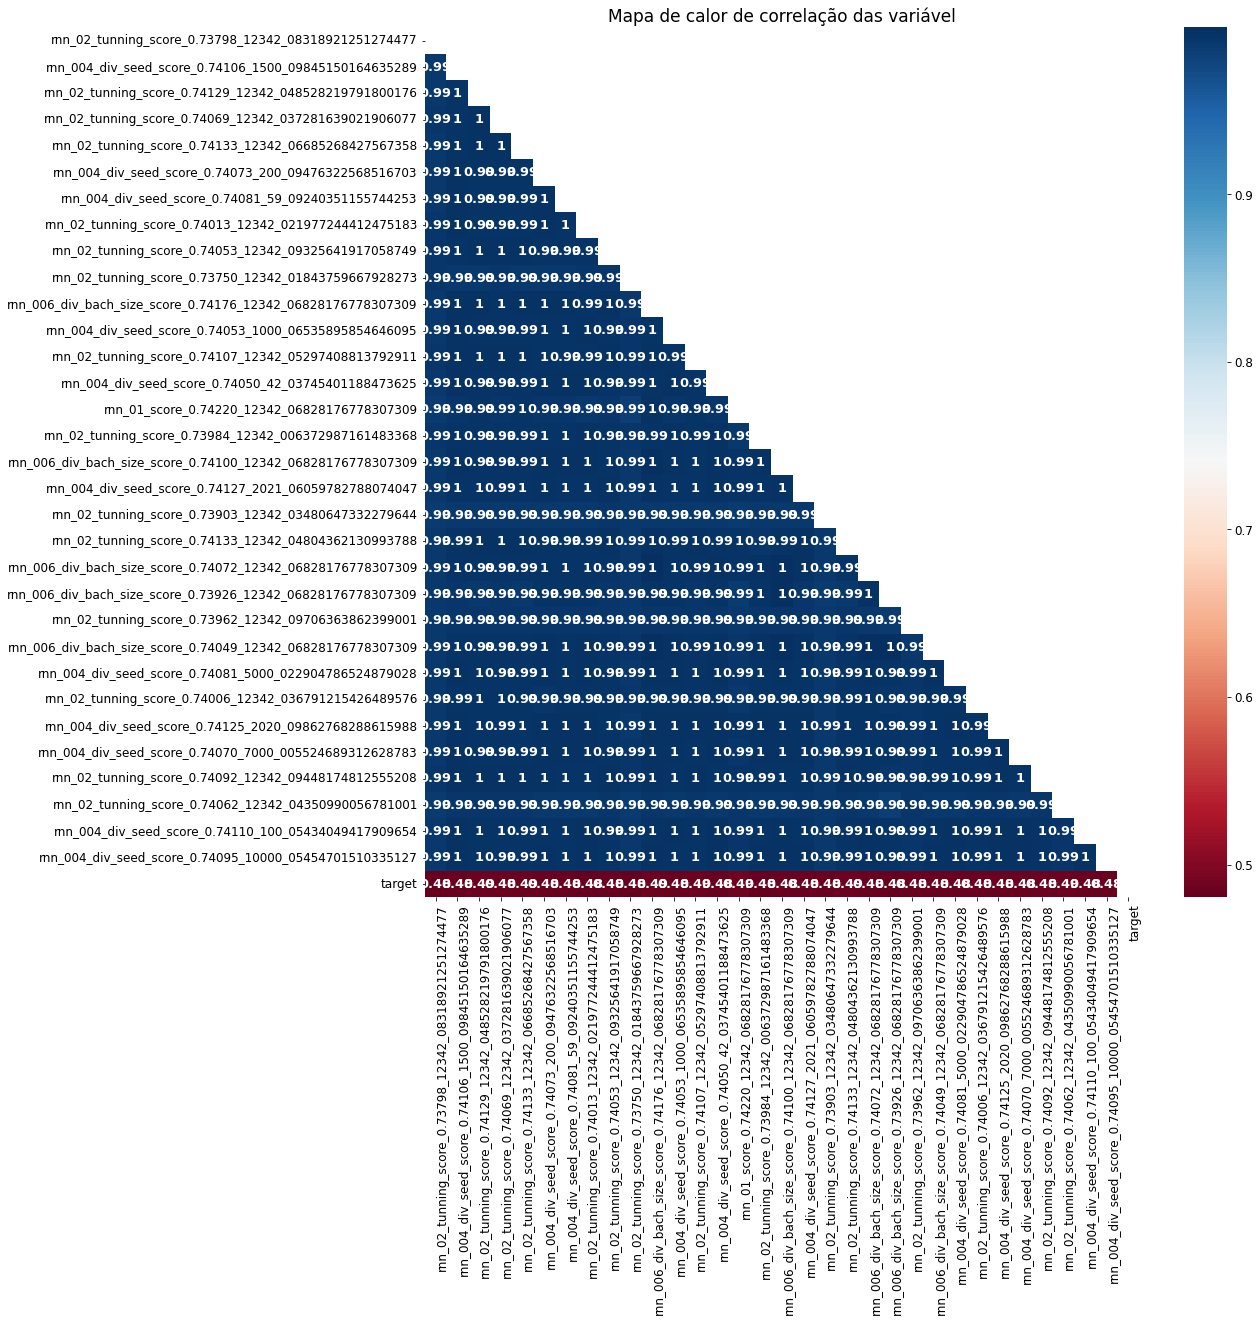

In [67]:
graf_corr(df_train_rnn)

Temos muitas previsões autocorrelacionadas, vamos fazer a exclusão de algumas.

In [68]:
corr_features = correlation(df_train_rnn, 0.9)
len(set(corr_features))

31

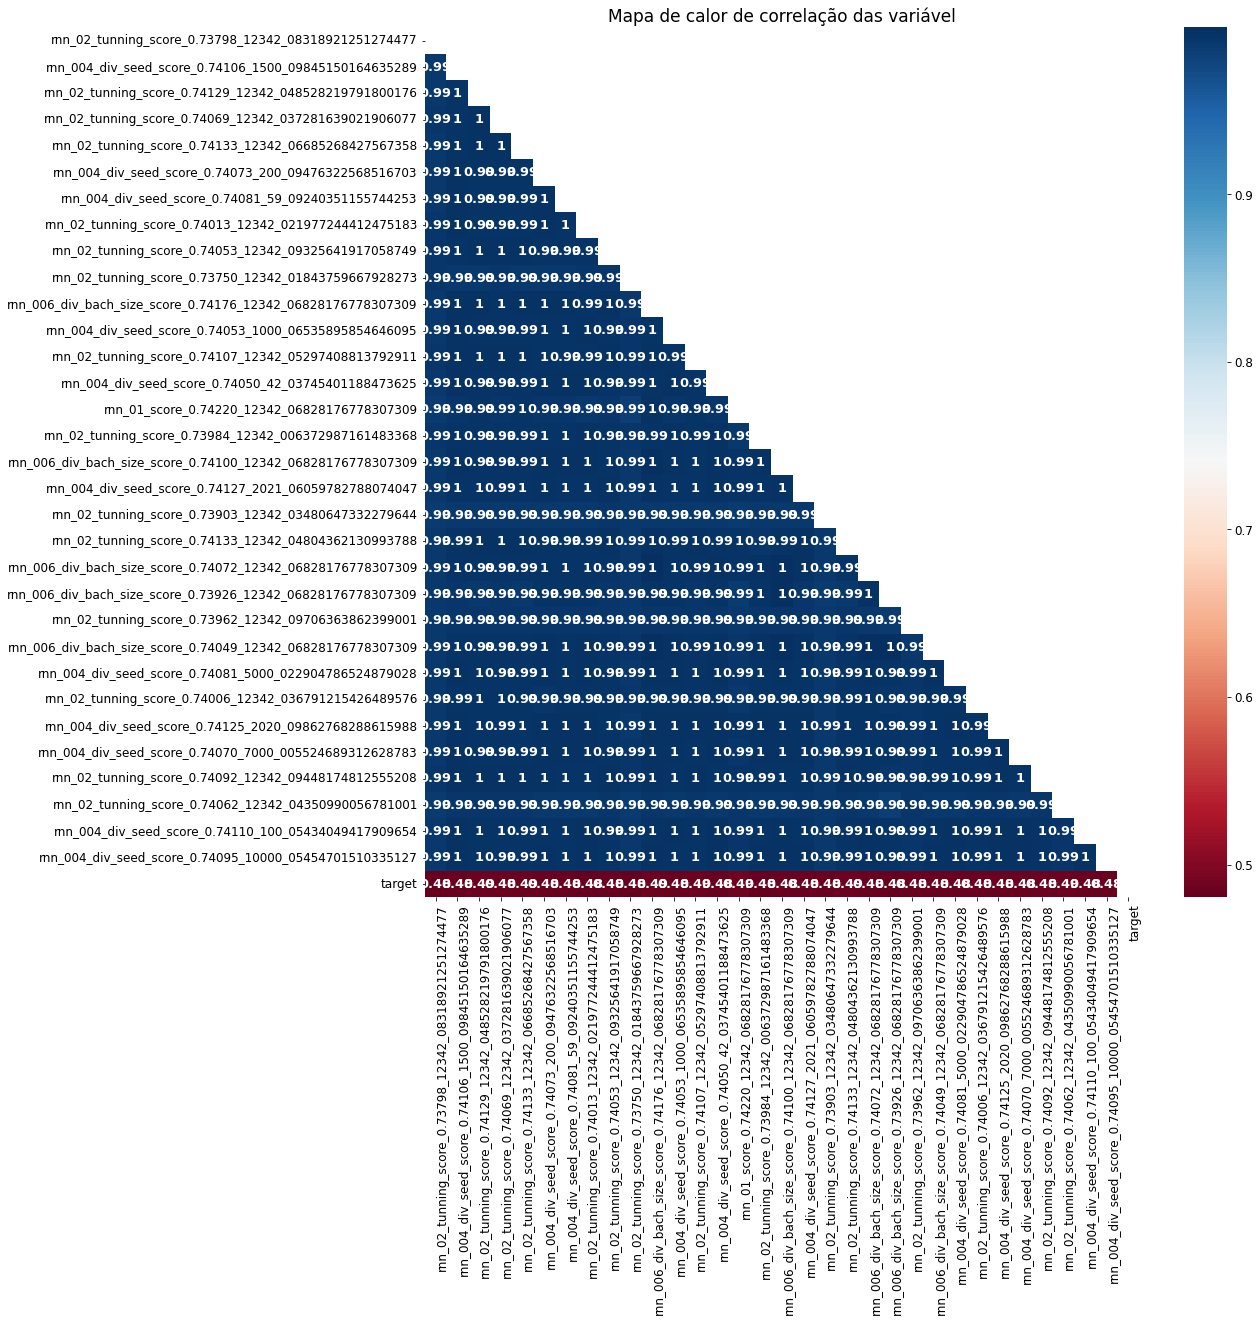

In [69]:
#df_train_lgbm.drop(labels=corr_features, axis=1, inplace=True)

graf_corr(df_train_rnn) 